# Eco-Logistics GRPO Training — v2 (hackathon submission)

**Theme:** #3.1 World Modeling / Professional Tasks (primary), #2 Long-Horizon Planning (secondary).

**What this notebook does:**
1. Installs TRL + OpenEnv + Unsloth
2. Connects to the hosted `eco-logistics` HF Space (configured for parallel rollouts)
3. Wraps the env with **non-stationary demand shocks** and a **competitor agent** that bids up shipping prices — strengthens the world-modeling story without pretending to be multi-agent
4. Normalizes the full dense reward (profit − shipping − carbon − storage + healthy-stock bonus) for GRPO
5. Logs 4 metrics per episode: total reward, profit, carbon usage, delivery success rate
6. Runs GRPO training
7. Produces 2 training curves (reward vs episodes, carbon efficiency vs episodes) for the pitch deck
8. Compares before/after agent behavior

**Hardware:** single T4 (free Colab) or A100 (HF credits). Uses Unsloth + LoRA to fit in <15GB VRAM.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q "transformers>=4.56.0,<5.0" "trl[vllm]==0.24.0" openenv-core unsloth "pandas<3.0.0" "numpy<2.4" matplotlib "huggingface-hub>=0.34.0,<1.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.0/180.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/

In [20]:
from huggingface_hub import login
from google.colab import userdata

try:
    # Fetch the token from Colab Secrets and assign it to the variable
    HF_TOKEN = userdata.get('HF_TOKEN')

    if HF_TOKEN:
        login(token=HF_TOKEN)
        print("Successfully logged into Hugging Face!")
    else:
        print("WARNING: Token retrieved but is empty.")

except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' was not found in your Colab Secrets. Make sure it is spelled exactly as 'HF_TOKEN' in the Secrets tab.")

Successfully logged into Hugging Face!


## 2. Configuration

In [21]:
# ---- Point this at your deployed HF Space ----
# IMPORTANT: your main.py on the Space MUST set max_concurrent_envs >= REQUIRED_CONCURRENT
# (printed below). With the current config that's 16, not 8.
ENV_URL = os.environ.get("ENV_URL", "https://lokeshrao226-eco-logistics.hf.space")

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# Primary training task. Also re-run on "net_zero_profit" for the hard-task story.
TASK_ID = "inventory_balanced"

# Tasks we sample across for diverse training prompts.
# Set to [TASK_ID] if your env doesn't expose all three.
TRAIN_TASK_IDS = ["restock_only", "inventory_balanced", "net_zero_profit"]

# GRPO hyperparameters
NUM_GENERATIONS = 4
PER_DEVICE_BATCH = 1
GRAD_ACCUM_STEPS = 4
MAX_STEPS = 50        # was 100 — halved for T4 speed (GRPO trend visible by ~30)
# NOTE: max_completion_length is set in GRPOConfig (cell 23) to 2048 — a
# 10-object JSON array needs ~500-700 tokens. Don't redefine it here.
MAX_ENV_STEPS = 10
LEARNING_RATE = 5e-6

# Dataset diversity — NEW in Tier 1 patch
N_UNIQUE_PROMPTS = 50       # distinct initial-state prompts (was: 10)
TRAIN_SEED_RANGE = (0, 50)  # inclusive start, exclusive end
EVAL_SEED_RANGE  = (500, 510)  # held out for BEFORE/AFTER eval

# World-modeling wrapper knobs (client-side, no env changes needed)
DEMAND_SHOCK_PROB = 0.15
DEMAND_SHOCK_MULT = 2.5
COMPETITOR_BID_PROB = 0.20
COMPETITOR_BID_MULT = 1.8

# Concurrency guard
REQUIRED_CONCURRENT = NUM_GENERATIONS * PER_DEVICE_BATCH * GRAD_ACCUM_STEPS
print(f"HF Space must support max_concurrent_envs >= {REQUIRED_CONCURRENT}")
print(f"Training {MODEL_NAME} on task={TASK_ID} against {ENV_URL}")
print(f"Dataset: {N_UNIQUE_PROMPTS} unique prompts across {len(TRAIN_TASK_IDS)} task(s)")


HF Space must support max_concurrent_envs >= 16
Training Qwen/Qwen2.5-1.5B-Instruct on task=inventory_balanced against https://lokeshrao226-eco-logistics.hf.space
Dataset: 50 unique prompts across 3 task(s)


## 3. Smoke-test the env

In [22]:
import requests
import time as _time
import uuid # Added for session_id generation

def _post_with_retry(url, *, json=None, headers=None, timeout=30,
                     max_retries=6, base_delay=2.0):
    delay = base_delay
    for attempt in range(max_retries + 1):
        r = requests.post(url, json=json, headers=headers, timeout=timeout)

        if r.status_code not in (429, 500, 502, 503):
            r.raise_for_status()
            return r

        retry_after = r.headers.get("Retry-After")
        wait = float(retry_after) if retry_after else min(delay, 60.0)
        if attempt < max_retries:
            print(f"  [retry {r.status_code}] {url.rsplit('/',1)[-1]} — "
                  f"waiting {wait:.1f}s (attempt {attempt+1}/{max_retries})")
            _time.sleep(wait)
            delay *= 2
        else:
            r.raise_for_status()
    return r # unreachable, but keeps linters happy

# 1. Initialize headers for the session
session_id = f"test-{uuid.uuid4().hex[:12]}"
headers = {"X-Session-Id": session_id}

# 2. Reset the environment first (logical order for a smoke test)
r = _post_with_retry(f"{ENV_URL}/reset", json={"task_id": TASK_ID},
                     headers=headers, timeout=30)
initial_obs = r.json()
print("Reset OK. Observation keys:", list(initial_obs.keys()))

# 3. Define a dummy action
dummy_action = {
    "ship_amount": 0.0,
    "origin_city": "Seattle",
    "destination_city": "Chicago",
    "speed_mode": "Rail",
}

# 4. Take a step with the dummy action
r = _post_with_retry(f"{ENV_URL}/step", json=dummy_action,
                     headers=headers, timeout=30)
step_resp = r.json()
print("Step OK. Reward breakdown:", step_resp.get("reward"))

Reset OK. Observation keys: ['current_inventory', 'pending_shipments', 'current_demand', 'carbon_credit_balance', 'step_number', 'total_steps', 'weather_alert', 'cumulative_profit', 'cumulative_carbon']
Step OK. Reward breakdown: {'sales_revenue': 431.0, 'shipping_cost': 0.0, 'carbon_penalty': 0.0, 'storage_fee': 96.65, 'healthy_stock_bonus': 0.1, 'total': 334.45}


In [23]:
# ── Session ID pool (fixes 429 "Too many concurrent sessions") ───────────────
#
# Our app (main.py) caps MAX_SESSIONS at 32. If we create a fresh UUID per
# request, we fill the pool after 32 resets and everything 429s until TTL.
#
# Fix: pool of reusable session IDs. Pool size = 8 stays well under the cap
# AND is larger than any single GRPO batch (num_generations * grad_accum = 16
# uses a DIFFERENT pool per-worker, see env_reward_func).
#
# For sequential collection we rotate through the pool, so after pool_size
# resets the app reuses sessions in-place (env.reset() just re-initializes
# that session's env state).

import itertools

class SessionPool:
    """Thread-safe rotating pool of session IDs."""
    def __init__(self, size: int = 8, prefix: str = "pool"):
        self._ids = [f"{prefix}-{i:02d}-{uuid.uuid4().hex[:6]}" for i in range(size)]
        self._cycle = itertools.cycle(self._ids)
        self._lock = threading.Lock() if False else None  # itertools.cycle is GIL-safe

    def next(self) -> str:
        return next(self._cycle)

    def all(self) -> list[str]:
        return list(self._ids)

# Need threading import for the future-proof lock (unused for now)
import threading

# Global pool for sequential callers (prompt collection, baseline eval, AFTER eval)
SEQUENTIAL_POOL = SessionPool(size=8, prefix="seq")

# Separate larger pool for parallel GRPO training callers
GRPO_POOL = SessionPool(size=24, prefix="grpo")   # GRPO fires 16 parallel, 24 gives headroom

print(f"Session pools ready:")
print(f"  SEQUENTIAL_POOL: {len(SEQUENTIAL_POOL.all())} IDs for prompt collection + eval")
print(f"  GRPO_POOL:       {len(GRPO_POOL.all())} IDs for concurrent training rollouts")


Session pools ready:
  SEQUENTIAL_POOL: 8 IDs for prompt collection + eval
  GRPO_POOL:       24 IDs for concurrent training rollouts


## 4. World-modeling wrapper: non-stationary demand + competitor

These two knobs add genuine world-modeling complexity on top of the base env. They run **client-side** so we don't need to redeploy the Space:

- **Demand shock**: with probability `DEMAND_SHOCK_PROB` per step, multiply the observed `current_demand` by `DEMAND_SHOCK_MULT`. The agent sees the spike in its prompt and must react (ship more, use Air mode, etc).
- **Competitor bid**: with probability `COMPETITOR_BID_PROB`, a random route becomes 1.8x more expensive for that step. We surface this as a `weather_alert`-style warning so the agent has to route around it.

These change the **observation the agent sees** and the **reward it receives** after the env responds — they do NOT require modifying the environment itself. This keeps us Round-1-compliant while honestly increasing task difficulty.

In [24]:
# ── SCRIPTED DISRUPTOR (multi-agent + world modeling) ───────────────────────
#
# Replaces the basic random-shock world wrapper with a structured adversary
# that rotates between 4 hand-coded attack policies. Each attack is:
#  - Deterministic given (seed, step) — reproducible eval
#  - Surfaced to the agent via observation['weather_alert'] — agent can learn
#  - Realistic in supply chain terms
#
# This makes Eco-Logistics a multi-agent environment (Theme 1.1) AND a
# world-modeling task (Theme 3.1): the agent must model what the disruptor
# might do next.

import random

CITIES = ["Seattle", "Chicago", "NYC"]

DISRUPTOR_ATTACK_PROB    = 0.30
DISRUPTOR_INTENSITY_MEAN = 2.5
DISRUPTOR_INTENSITY_STD  = 0.5
DISRUPTOR_CONTEST_COST   = 1.8


def _attack_random_target(obs, rng):
    """A1: Random demand spike on a random city. Baseline threat."""
    city = rng.choice(list(obs["current_demand"].keys()))
    mult = max(1.5, rng.gauss(DISRUPTOR_INTENSITY_MEAN, DISRUPTOR_INTENSITY_STD))
    new = {**obs, "current_demand": {**obs["current_demand"]}}
    new["current_demand"][city] = new["current_demand"][city] * mult
    return new, {"attack": "random_target", "demand_mult": round(mult, 2),
                 "alert": f"DEMAND_SPIKE in {city} (×{mult:.1f})"}


def _attack_highest_inventory(obs, rng):
    """A2: Hits the city with HIGHEST inventory. Punishes over-stockpiling."""
    inv = obs.get("current_inventory", {})
    if not inv:
        return _attack_random_target(obs, rng)
    target = max(inv.items(), key=lambda kv: kv[1])[0]
    mult = max(1.5, rng.gauss(DISRUPTOR_INTENSITY_MEAN + 0.3, DISRUPTOR_INTENSITY_STD))
    new = {**obs, "current_demand": {**obs["current_demand"]}}
    new["current_demand"][target] = new["current_demand"][target] * mult
    return new, {"attack": "highest_inventory", "demand_mult": round(mult, 2),
                 "alert": f"DEMAND_SPIKE in {target} (×{mult:.1f}) — high-inventory drain"}


def _attack_coordinated_double(obs, rng):
    """A3: Spike demand in TWO cities simultaneously. Multi-front pressure."""
    cities = list(obs["current_demand"].keys())
    if len(cities) < 2:
        return _attack_random_target(obs, rng)
    t1, t2 = rng.sample(cities, 2)
    m1 = max(1.5, rng.gauss(DISRUPTOR_INTENSITY_MEAN, DISRUPTOR_INTENSITY_STD))
    m2 = max(1.5, rng.gauss(DISRUPTOR_INTENSITY_MEAN, DISRUPTOR_INTENSITY_STD))
    new = {**obs, "current_demand": {**obs["current_demand"]}}
    new["current_demand"][t1] *= m1
    new["current_demand"][t2] *= m2
    return new, {"attack": "coordinated_double", "demand_mult": round((m1+m2)/2, 2),
                 "alert": f"COORDINATED_SPIKE in {t1}(×{m1:.1f}) AND {t2}(×{m2:.1f})"}


def _attack_route_contester(obs, rng):
    """A4: Competitor bids on a route, making it more expensive."""
    cities = list(obs.get("current_inventory", {"Seattle":0,"Chicago":0,"NYC":0}).keys())
    if len(cities) < 2:
        return obs, {"attack": "noop", "demand_mult": 1.0, "alert": ""}
    o, d = rng.sample(cities, 2)
    return obs, {"attack": "route_contester", "contested_route": (o, d),
                 "demand_mult": 1.0,
                 "alert": f"COMPETITOR_BID on {o}→{d} (cost ×{DISRUPTOR_CONTEST_COST})"}


_DISRUPTOR_ATTACKS = [_attack_random_target, _attack_highest_inventory,
                      _attack_coordinated_double, _attack_route_contester]


def apply_world_wrapper(obs: dict, rng: random.Random) -> tuple[dict, dict]:
    """Disruptor wrapper. Returns (modified_obs, shock_state).
    Same signature as the original apply_world_wrapper for backwards compat."""
    shock_state = {
        "demand_shocked":   False,
        "contested_route":  None,
        "attack_type":      None,
        "attack_intensity": 1.0,
    }

    if rng.random() > DISRUPTOR_ATTACK_PROB:
        return obs, shock_state

    attack_fn = rng.choice(_DISRUPTOR_ATTACKS)
    new_obs, meta = attack_fn(obs, rng)

    shock_state["attack_type"]      = meta["attack"]
    shock_state["attack_intensity"] = meta.get("demand_mult", 1.0)
    if meta["attack"] in ("random_target", "highest_inventory", "coordinated_double"):
        shock_state["demand_shocked"] = True
    if meta["attack"] == "route_contester":
        shock_state["contested_route"] = meta["contested_route"]

    new_obs = {**new_obs}
    existing = new_obs.get("weather_alert") or ""
    if existing and existing != "clear":
        new_obs["weather_alert"] = f"{existing} | {meta['alert']}"
    else:
        new_obs["weather_alert"] = meta["alert"]

    return new_obs, shock_state


def apply_reward_wrapper(raw_reward: dict, action: dict, shock_state: dict) -> dict:
    """Apply route-contester cost penalty post-hoc (env doesn't know about it)."""
    adjusted = dict(raw_reward)
    contested = shock_state.get("contested_route")
    if contested is not None:
        if (action.get("origin_city"), action.get("destination_city")) == contested:
            extra = adjusted.get("shipping_cost", 0) * (DISRUPTOR_CONTEST_COST - 1.0)
            adjusted["shipping_cost"] = adjusted.get("shipping_cost", 0) + extra
            adjusted["total"] = adjusted.get("total", 0) - extra
    return adjusted


# Smoke test
print("Disruptor wrapper loaded. Smoke test:")
_rng = random.Random(42)
_counts = {"none": 0, "random_target": 0, "highest_inventory": 0,
           "coordinated_double": 0, "route_contester": 0}
_test_obs = {
    "current_inventory": {"Seattle": 50, "Chicago": 20, "NYC": 30},
    "current_demand":    {"Seattle": 5, "Chicago": 8, "NYC": 6},
    "weather_alert":     "clear",
}
for _ in range(100):
    _, _ss = apply_world_wrapper(_test_obs, _rng)
    if _ss["attack_type"] is None:
        _counts["none"] += 1
    else:
        _counts[_ss["attack_type"]] += 1
print(f"  Over 100 trials: {_counts}")
print(f"  Expected ~70 none + ~7-8 of each attack (p={DISRUPTOR_ATTACK_PROB})")


In [25]:
SYSTEM_PROMPT = """You are an AI supply chain manager for a 3-warehouse network \
(Seattle, Chicago, NYC).

You are planning an ENTIRE {n}-step episode UPFRONT. The environment will inject \
non-stationary demand shocks and competitor bids mid-episode; your plan must be \
robust to these surprises before they arrive.

Output EXACTLY one JSON array containing EXACTLY {n} action objects — one per step \
in order:
[
  {{"ship_amount": <float ≥ 0>, "origin_city": <"Seattle"|"Chicago"|"NYC">,
    "destination_city": <"Seattle"|"Chicago"|"NYC">, "speed_mode": <"Air"|"Rail">}},
  ... (repeat for all {n} steps)
]

Planning rules:
- Rail: cheap, low-carbon, slow (3-step transit). Prefer for routine restocking.
- Air: fast (1-step), expensive, high-carbon. Reserve for demand-spike response.
- ship_amount=0 is a valid no-op — use it to hold buffer stock against shocks.
- Defensive routing: spread shipments across multiple origin→destination pairs so
  a single contested route cannot block all supply.
- If weather_alert warns of a disruption, plan an alternative route in later steps.

Respond with ONLY the JSON array. No explanation, no markdown, no extra text.""".format(
    n=MAX_ENV_STEPS
)


def format_observation_prompt(obs: dict) -> str:
    return (
        f"Initial state — plan all {obs['total_steps']} steps now.\n"
        f"Step {obs['step_number']}/{obs['total_steps']}\n"
        f"Inventory: {obs['current_inventory']}\n"
        f"Demand forecast (step 0): {obs['current_demand']}\n"
        f"Pending shipments: {obs.get('pending_shipments', [])}\n"
        f"Carbon credits left: {obs['carbon_credit_balance']:.1f}\n"
        f"Cumulative profit: {obs.get('cumulative_profit', 0):.2f}\n"
        f"Weather/market alert: {obs.get('weather_alert') or 'clear'}\n"
        f"\nYour 10-step plan (JSON array only):"
    )

In [26]:
# ── Cell 46 ──────────────────────────────────────────────────────────────────
import json
import re

# Bug fix: use dict(...) inside the comprehension so each slot is a distinct
# dict. Previously all 10 slots pointed to the same dict reference.
SAFE_FALLBACK_ACTIONS: list[dict] = [
    {
        "ship_amount": 0.0,
        "origin_city": "Seattle",
        "destination_city": "Chicago",
        "speed_mode": "Rail",
    }
    for _ in range(MAX_ENV_STEPS)
]
# Force independence (defensive — in case callers mutate entries)
SAFE_FALLBACK_ACTIONS = [dict(a) for a in SAFE_FALLBACK_ACTIONS]

_REQUIRED_KEYS = {"ship_amount", "origin_city", "destination_city", "speed_mode"}
_VALID_CITIES  = {"Seattle", "Chicago", "NYC"}
_VALID_SPEEDS  = {"Air", "Rail"}


def parse_action_array(completion: str) -> tuple[list[dict], bool]:
    m = re.search(r"\[.*\]", completion, re.DOTALL)
    if not m:
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
    try:
        arr = json.loads(m.group(0))
    except (json.JSONDecodeError, ValueError):
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False

    if not isinstance(arr, list) or len(arr) != MAX_ENV_STEPS:
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False

    for item in arr:
        if not isinstance(item, dict):
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if not _REQUIRED_KEYS.issubset(item.keys()):
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if item["origin_city"] not in _VALID_CITIES:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if item["destination_city"] not in _VALID_CITIES:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if item["origin_city"] == item["destination_city"]:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if item["speed_mode"] not in _VALID_SPEEDS:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if not isinstance(item["ship_amount"], (int, float)) or item["ship_amount"] < 0:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False

    return arr, True


## 6. Episode rollout with full metric logging

Returns the 4 metrics the judges want to see:
- `total_reward` — summed normalized reward (what GRPO optimizes)
- `profit` — summed sales_revenue − shipping_cost (business metric)
- `carbon_used` — cumulative carbon emissions (sustainability metric)
- `delivery_success_rate` — fraction of demand fulfilled (operations metric)
- `valid_action_rate` — fraction of model outputs that parsed as valid JSON (diagnostic)

In [27]:


def run_episode(
    generate_fn,
    task_id: str = TASK_ID,
    max_steps: int = MAX_ENV_STEPS,
    env_url: str = ENV_URL,
    seed: int | None = None,
):
    """Run one full episode under the Upfront Trajectory Planning protocol."""
    rng        = random.Random(seed)
    session_id = SEQUENTIAL_POOL.next()
    headers    = {"X-Session-Id": session_id}

    r = _post_with_retry(
        f"{env_url}/reset", json={"task_id": task_id, "seed": seed},
        headers=headers, timeout=30
    )
    obs = r.json()

    wrapped_obs_0, _ = apply_world_wrapper(obs, rng)
    user_body = format_observation_prompt(wrapped_obs_0)
    full_prompt = build_chat_prompt(user_body)   # ← uses apply_chat_template
    completion = generate_fn(full_prompt)
    parsed_actions, was_valid = parse_action_array(completion)

    trajectory     = []
    total_reward   = 0.0
    total_profit   = 0.0
    total_carbon   = 0.0
    total_demand   = 0.0
    total_fulfilled = 0.0
    UNIT_PRICE     = 10.0

    for step_idx in range(max_steps):
        wrapped_obs, shock_state = apply_world_wrapper(obs, rng)
        action = parsed_actions[step_idx]

        r = _post_with_retry(
            f"{env_url}/step", json=action,
            headers=headers, timeout=30
        )
        step_resp       = r.json()
        raw_reward      = step_resp.get("reward", {})
        adjusted_reward = apply_reward_wrapper(raw_reward, action, shock_state)
        step_reward     = adjusted_reward.get("total", 0.0)

        total_reward   += step_reward
        total_profit   += (adjusted_reward.get("sales_revenue", 0)
                           - adjusted_reward.get("shipping_cost", 0))
        total_carbon   += adjusted_reward.get("carbon_penalty", 0)

        step_demand      = sum(wrapped_obs["current_demand"].values())
        total_demand    += step_demand
        total_fulfilled += adjusted_reward.get("sales_revenue", 0) / UNIT_PRICE

        obs = step_resp.get("observation", obs)
        trajectory.append({
            "step":      step_idx,
            "action":    action,
            "valid":     was_valid,
            "reward":    step_reward,
            "profit":    adjusted_reward.get("sales_revenue", 0) - adjusted_reward.get("shipping_cost", 0),
            "carbon":    adjusted_reward.get("carbon_penalty", 0),
            "shocked":   shock_state["demand_shocked"],
            "contested": shock_state["contested_route"] is not None,
        })

        if step_resp.get("done"):
            break

    try:
        g = _post_with_retry(
            f"{env_url}/grader", json={"task_id": task_id},
            headers=headers, timeout=30
        )
        grader_score = g.json().get("score", 0.0)
    except Exception:
        grader_score = 0.0

    return {
        "total_reward":          total_reward,
        "profit":                total_profit,
        "carbon_used":           total_carbon,
        "carbon_efficiency":     total_profit / max(1.0, total_carbon),
        "delivery_success_rate": total_fulfilled / max(1.0, total_demand),
        "valid_action_rate":     float(was_valid),
        "grader_score":          grader_score,
        "trajectory":            trajectory,
    }


## 7. Load model + baseline eval

In [28]:
# torchcodec conflicts with unsloth's torch build — remove it before loading.
# If this is the first time in the session, we need to restart the runtime
# after uninstalling so the import cache is cleared.
import importlib, sys, subprocess

_had_torchcodec = "torchcodec" in sys.modules
subprocess.run(["pip", "uninstall", "-y", "torchcodec"], check=False)

if _had_torchcodec:
    print("torchcodec was loaded. RESTART THE RUNTIME now, then re-run from cell 18.")
else:
    print("torchcodec uninstalled (not previously imported — safe to continue).")


torchcodec uninstalled (not previously imported — safe to continue).


In [29]:
# Load Qwen-2.5-1.5B-Instruct with Unsloth 4-bit + attach LoRA adapter
from unsloth import FastLanguageModel
import torch
import numpy as np

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=3072,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

# Sanity: confirm tokenizer has a chat template (Qwen-2.5-Instruct ships with one)
assert tokenizer.chat_template is not None, "Tokenizer has no chat_template — wrong model?"
print(f"Model loaded. Tokenizer chat template: {'present' if tokenizer.chat_template else 'MISSING'}")
print(f"EOS token: {tokenizer.eos_token!r}  (id: {tokenizer.eos_token_id})")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.10.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded. Tokenizer chat template: present
EOS token: '<|im_end|>'  (id: 151645)


In [30]:
def build_chat_prompt(user_body: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_body},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
print("build_chat_prompt defined:", build_chat_prompt is not None)

build_chat_prompt defined: True


In [32]:
# ── Permissive city parsing: accept "New York City", "New York", "Seattle WA", etc.
import json, re

_CITY_ALIASES = {
    "new york city": "NYC",
    "new york":      "NYC",
    "ny":            "NYC",
    "nyc":           "NYC",
    "seattle":       "Seattle",
    "seattle wa":    "Seattle",
    "chicago":       "Chicago",
    "chicago il":    "Chicago",
}

def _canon_city(s):
    if not isinstance(s, str):
        return None
    return _CITY_ALIASES.get(s.strip().lower())

def parse_action_array(completion: str) -> tuple[list[dict], bool]:
    m = re.search(r"\[.*\]", completion, re.DOTALL)
    if not m:
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
    try:
        arr = json.loads(m.group(0))
    except (json.JSONDecodeError, ValueError):
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False

    if not isinstance(arr, list) or len(arr) != MAX_ENV_STEPS:
        return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False

    normalized = []
    for item in arr:
        if not isinstance(item, dict):
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if not _REQUIRED_KEYS.issubset(item.keys()):
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        o = _canon_city(item["origin_city"])
        d = _canon_city(item["destination_city"])
        if o is None or d is None or o == d:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if item["speed_mode"] not in _VALID_SPEEDS:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        if not isinstance(item["ship_amount"], (int, float)) or item["ship_amount"] < 0:
            return [dict(a) for a in SAFE_FALLBACK_ACTIONS], False
        # Normalize city names so the action sent to /step uses what the env expects
        normalized.append({
            "ship_amount":      float(item["ship_amount"]),
            "origin_city":      o,
            "destination_city": d,
            "speed_mode":       item["speed_mode"],
        })
    return normalized, True


# Also tighten the system prompt so the model learns the canonical names faster
SYSTEM_PROMPT = SYSTEM_PROMPT + "\n\nCity name rules: use EXACTLY 'Seattle', 'Chicago', 'NYC'. Never spell out 'New York City' or 'New York' — always 'NYC'."

# ── Re-run the sanity check with the fixed parser
print("Re-running sanity check with permissive parser...\n")
_r = _post_with_retry(f"{ENV_URL}/reset", json={"task_id": TASK_ID, "seed": 9999},
                      headers={"X-Session-Id": SEQUENTIAL_POOL.next()}, timeout=30)
_user_body = format_observation_prompt(_r.json())
_full_prompt = build_chat_prompt(_user_body)
_completion = eager_generate(_full_prompt)
_parsed, _valid = parse_action_array(_completion)
print(f"Parse result: valid={_valid}, actions parsed: {len(_parsed)}")
if _valid:
    print(f"First parsed action: {_parsed[0]}")
    print("\n✓ SANITY CHECK PASSED — safe to run baselines + training.")
else:
    print(f"\n✗ Still failing. Raw completion:\n{_completion[:500]}")

Re-running sanity check with permissive parser...

Parse result: valid=True, actions parsed: 10
First parsed action: {'ship_amount': 20.0, 'origin_city': 'Seattle', 'destination_city': 'Chicago', 'speed_mode': 'Air'}

✓ SANITY CHECK PASSED — safe to run baselines + training.


In [33]:
def eager_generate(prompt: str) -> str:
    """Inference-mode generate. SAFE ONLY OUTSIDE GRPO TRAINING.

    Calling FastLanguageModel.for_inference during training corrupts LoRA
    adapter state. Use this for baseline eval and post-training eval only.
    """
    FastLanguageModel.for_inference(model)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=1024,   # 10-action JSON array needs ~500-700 tokens
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    completion = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return completion


# ─── Additional baselines: random policy + heuristic policy ─────────────────
# These let us show that the improvement isn't just "base Qwen sucks at JSON".

def random_policy_generate(prompt: str, rng=None) -> str:
    """Emits a valid 10-action JSON array with random choices."""
    import random as _r
    rng = rng or _r.Random()
    actions = []
    for _ in range(MAX_ENV_STEPS):
        o = rng.choice(list(_VALID_CITIES))
        d = rng.choice([c for c in _VALID_CITIES if c != o])
        actions.append({
            "ship_amount": round(rng.uniform(0, 30), 1),
            "origin_city": o,
            "destination_city": d,
            "speed_mode": rng.choice(list(_VALID_SPEEDS)),
        })
    return json.dumps(actions)


def heuristic_policy_generate(prompt: str) -> str:
    """Hand-coded rule-of-thumb: ship rail from highest-inv to lowest-inv city.

    Parses the inventory dict out of the prompt text. This is a reasonable
    non-learned baseline — matches what a careful engineer would write in 20 min.
    """
    # Extract inventory line from the prompt
    m = re.search(r"Inventory:\s*(\{[^}]+\})", prompt)
    actions = []
    if m:
        try:
            inv = json.loads(m.group(1).replace("'", '"'))
            # Order cities by inventory ascending; ship from richest to poorest
            cities_sorted = sorted(inv.items(), key=lambda kv: kv[1])
            poorest = cities_sorted[0][0]
            richest = cities_sorted[-1][0]
            amount = max(0.0, (inv[richest] - inv[poorest]) / 2)
            for _ in range(MAX_ENV_STEPS):
                actions.append({
                    "ship_amount": round(amount, 1),
                    "origin_city": richest,
                    "destination_city": poorest,
                    "speed_mode": "Rail",
                })
            return json.dumps(actions)
        except Exception:
            pass
    # Fallback
    return json.dumps([dict(a) for a in SAFE_FALLBACK_ACTIONS])


print("Running 10 BASELINE episodes (base Qwen, no training)...")
baseline_results = [run_episode(eager_generate, seed=500+i) for i in range(10)]

print("\nRunning 10 RANDOM-POLICY baseline episodes...")
import random as _rpy
_rng = _rpy.Random(123)
random_results = [run_episode(lambda p: random_policy_generate(p, _rng), seed=500+i) for i in range(10)]

print("\nRunning 10 HEURISTIC-POLICY baseline episodes...")
heuristic_results = [run_episode(heuristic_policy_generate, seed=500+i) for i in range(10)]


def summarize(results, label):
    print(f"\n=== {label} ===")
    for key in ["total_reward", "profit", "carbon_used", "carbon_efficiency",
                "delivery_success_rate", "valid_action_rate", "grader_score"]:
        vals = [r[key] for r in results]
        print(f"  {key:25s}: {np.mean(vals):+8.3f} ± {np.std(vals):.3f}")

summarize(random_results, "RANDOM POLICY")
summarize(heuristic_results, "HEURISTIC POLICY")
summarize(baseline_results, "BEFORE TRAINING (base Qwen)")


Running 10 BASELINE episodes (base Qwen, no training)...

Running 10 RANDOM-POLICY baseline episodes...

Running 10 HEURISTIC-POLICY baseline episodes...

=== RANDOM POLICY ===
  total_reward             : +1919.920 ± 565.665
  profit                   : +3964.747 ± 291.853
  carbon_used              : +1134.786 ± 313.000
  carbon_efficiency        :   +3.863 ± 1.402
  delivery_success_rate    :   +0.873 ± 0.049
  valid_action_rate        :   +1.000 ± 0.000
  grader_score             :   +0.131 ± 0.142

=== HEURISTIC POLICY ===
  total_reward             : +2147.782 ± 206.514
  profit                   : +3558.108 ± 195.701
  carbon_used              : +450.000 ± 0.000
  carbon_efficiency        :   +7.907 ± 0.435
  delivery_success_rate    :   +0.715 ± 0.040
  valid_action_rate        :   +1.000 ± 0.000
  grader_score             :   +0.040 ± 0.003

=== BEFORE TRAINING (base Qwen) ===
  total_reward             : +1364.203 ± 3957.370
  profit                   : +3793.070 ± 1770.747
 

## 8. GRPO training with normalized dense reward

Key points:
- **Reward normalization**: we divide episode returns by a running std to give GRPO stable advantages. GRPO's group-relative advantage already normalizes within a group; this extra normalization helps across groups.
- **Full dense signal preserved**: `total_reward` is computed from all four components (revenue − shipping − carbon − storage + bonus) plus our wrapper adjustments.
- **Per-step metric logging**: we record profit/carbon/delivery alongside reward so the training curves show tradeoffs, not just one number.

In [34]:
# ── Cell 56 — logging state + reward function ────────────────────────────────

if "global_step_counter" not in dir():
    global_step_counter = {"n": 0}

if "training_log" not in dir():
    training_log = {
        "grpo_step":        [],
        "mean_reward":      [],
        "mean_grader":      [],
        "mean_profit":      [],
        "mean_carbon":      [],
        "carbon_efficiency":[],
        "delivery_rate":    [],
        "valid_rate":       [],
    }

FALLBACK_ACTION = {
    "ship_amount": 0.0,
    "origin_city": "Seattle",
    "destination_city": "Chicago",
    "speed_mode": "Rail",
}


def env_reward_func(prompts, completions, **kwargs):
    rewards        = []
    batch_valid    = []
    batch_grader   = []
    batch_delivery = []
    batch_profit   = []
    batch_carbon   = []

    for completion in completions:
        parsed_actions, was_valid = parse_action_array(completion)

        # Pool rotation — 24 session IDs reused across all GRPO calls.
        # main.py's MAX_SESSIONS=32 has headroom for this.
        session_id = GRPO_POOL.next()
        headers    = {"X-Session-Id": session_id}

        total_reward         = 0.0
        total_profit_episode = 0.0
        total_carbon_episode = 0.0
        total_demand         = 0.0
        total_fulfilled      = 0.0
        grader_score         = 0.0
        UNIT_PRICE           = 10.0

        try:
            r = _post_with_retry(
                f"{ENV_URL}/reset", json={"task_id": TASK_ID},
                headers=headers, timeout=30
            )
            obs = r.json()

            for step_idx in range(MAX_ENV_STEPS):
                wrapped_obs, shock_state = apply_world_wrapper(
                    obs, random.Random(session_id + str(step_idx))
                )

                action = parsed_actions[step_idx]

                r = _post_with_retry(
                    f"{ENV_URL}/step", json=action,
                    headers=headers, timeout=30
                )
                raw_step_resp   = r.json()
                raw_reward_dict = raw_step_resp.get("reward", {})
                adjusted_reward = apply_reward_wrapper(raw_reward_dict, action, shock_state)

                total_reward         += adjusted_reward.get("total", 0.0)
                total_profit_episode += (
                    adjusted_reward.get("sales_revenue", 0)
                    - adjusted_reward.get("shipping_cost", 0)
                )
                total_carbon_episode += adjusted_reward.get("carbon_penalty", 0)

                demand           = sum(wrapped_obs.get("current_demand", {}).values())
                total_demand    += demand
                total_fulfilled += adjusted_reward.get("sales_revenue", 0.0) / UNIT_PRICE

                obs = raw_step_resp.get("observation", obs)
                if raw_step_resp.get("done"):
                    break

            try:
                g = _post_with_retry(
                    f"{ENV_URL}/grader", json={"task_id": TASK_ID},
                    headers=headers, timeout=30
                )
                grader_score = g.json().get("score", 0.0)
            except Exception:
                grader_score = 0.0

        except Exception as e:
            print(f"[env_reward_func] episode error: {e}")
            total_reward         = 0.0
            total_profit_episode = 0.0
            total_carbon_episode = 0.0
            grader_score         = 0.0

        if not was_valid:
            final_reward = -1000.0  # Nuke the reward if it can't format
        else:
            final_reward = total_reward

        rewards.append(float(final_reward))
        batch_valid.append(float(was_valid))
        batch_grader.append(grader_score)
        batch_delivery.append(total_fulfilled / max(1.0, total_demand))
        batch_profit.append(total_profit_episode)
        batch_carbon.append(total_carbon_episode)

    # Logging
    global_step_counter["n"] += 1
    training_log["grpo_step"].append(global_step_counter["n"])
    training_log["mean_reward"].append(float(sum(rewards) / len(rewards)))
    training_log["mean_grader"].append(float(sum(batch_grader) / len(batch_grader)))
    training_log["delivery_rate"].append(float(sum(batch_delivery) / len(batch_delivery)))
    training_log["valid_rate"].append(float(sum(batch_valid) / len(batch_valid)))

    mean_profit = sum(batch_profit) / len(batch_profit) if batch_profit else 0.0
    mean_carbon = sum(batch_carbon) / len(batch_carbon) if batch_carbon else 0.0
    training_log["mean_profit"].append(mean_profit)
    training_log["mean_carbon"].append(mean_carbon)
    training_log["carbon_efficiency"].append(mean_profit / max(1.0, mean_carbon))

    if global_step_counter["n"] % 5 == 0:
        print(
            f"[step {global_step_counter['n']}] "
            f"reward={training_log['mean_reward'][-1]:.1f}  "
            f"grader={training_log['mean_grader'][-1]:.3f}  "
            f"delivery={training_log['delivery_rate'][-1]:.2%}  "
            f"valid={training_log['valid_rate'][-1]:.2%}  "
            f"profit={training_log['mean_profit'][-1]:.1f}  "
            f"carbon_eff={training_log['carbon_efficiency'][-1]:.1f}"
        )

    return rewards


In [35]:
!rm -rf /content/unsloth_compiled_cache

In [36]:
# ── NEW CELL — Dataset rebuild + GRPOTrainer (cache-backed, chat-template-fixed) ─

from trl import GRPOConfig, GRPOTrainer
import os, json as _json

INTER_EPISODE_DELAY = 2.0
PROMPT_CACHE_PATH = f"/content/drive/MyDrive/grpo-eco-logistics-prompts-cache.json"


def collect_episode_prompts(n_unique: int = N_UNIQUE_PROMPTS,
                             use_cache: bool = True) -> list[dict]:
    cached = []
    if use_cache and os.path.exists(PROMPT_CACHE_PATH):
        try:
            with open(PROMPT_CACHE_PATH) as f:
                cached = _json.load(f)
            print(f"Loaded {len(cached)} prompts from cache.")
            if len(cached) >= n_unique:
                # Still need to verify the cached prompts use the right template
                # (old cache from before chat-fix could have wrong tags)
                if "<|im_start|>" in cached[0].get("prompt", "") or \
                   "<|start_header_id|>" in cached[0].get("prompt", ""):
                    return cached[:n_unique]
                else:
                    print("Cache uses old chat template — invalidating.")
                    cached = []
            else:
                print(f"Need {n_unique - len(cached)} more — collecting...")
        except Exception as e:
            print(f"Cache read failed ({e}) — starting fresh")
            cached = []

    cached_keys = {(p.get("_seed"), p.get("_task_id")) for p in cached}
    prompts = list(cached)
    seed_start, seed_end = TRAIN_SEED_RANGE
    seeds = list(range(seed_start, seed_end))[:n_unique]

    consecutive_failures = 0
    MAX_CONSECUTIVE_FAILURES = 8

    for i, seed in enumerate(seeds):
        task_id = TRAIN_TASK_IDS[i % len(TRAIN_TASK_IDS)]
        if (seed, task_id) in cached_keys:
            continue

        session_id = SEQUENTIAL_POOL.next()
        headers = {"X-Session-Id": session_id}
        try:
            r = _post_with_retry(
                f"{ENV_URL}/reset",
                json={"task_id": task_id, "seed": seed},
                headers=headers, timeout=30
            )
            obs = r.json()
            wrapped_obs, _ = apply_world_wrapper(obs, random.Random(seed))
            user_body = format_observation_prompt(wrapped_obs)
            full_prompt = build_chat_prompt(user_body)   # ← fixed template
            prompts.append({"prompt": full_prompt, "_task_id": task_id, "_seed": seed})
            consecutive_failures = 0

            try:
                with open(PROMPT_CACHE_PATH, "w") as f:
                    _json.dump(prompts, f)
            except Exception as e:
                print(f"  cache write warn: {e}")

            if (i + 1) % 10 == 0:
                print(f"  {len(prompts)}/{n_unique} collected")

        except Exception as e:
            consecutive_failures += 1
            print(f"[collect] seed {seed} / {task_id} failed: {type(e).__name__}: {e}")
            if consecutive_failures >= MAX_CONSECUTIVE_FAILURES:
                print(f"  *** aborting after {consecutive_failures} consecutive failures ***")
                break
        _time.sleep(INTER_EPISODE_DELAY)

    return prompts


print(f"Collecting up to {N_UNIQUE_PROMPTS} diverse episode prompts...")
episode_prompts = collect_episode_prompts(n_unique=N_UNIQUE_PROMPTS, use_cache=True)
print(f"\nCollected {len(episode_prompts)} prompts.")

if len(episode_prompts) < 10:
    raise RuntimeError(f"Only {len(episode_prompts)} prompts — check /sessions on Space.")

unique_prompt_texts = {p["prompt"] for p in episode_prompts}
print(f"Unique prompts: {len(unique_prompt_texts)} / {len(episode_prompts)}")

# Sanity: verify one prompt uses the right template
_sample = episode_prompts[0]["prompt"]
assert "<|im_start|>" in _sample or "<|start_header_id|>" in _sample, \
    f"Prompt doesn't contain expected chat tags — template is wrong!\nSample: {_sample[:300]}"
print("✓ Prompt templates verified.")

if len(episode_prompts) < MAX_STEPS:
    import random as _rpy_ds
    _rng_ds = _rpy_ds.Random(42)
    extended = list(episode_prompts)
    while len(extended) < MAX_STEPS:
        extended.append(_rng_ds.choice(episode_prompts))
    episode_prompts = extended
episode_prompts = episode_prompts[:MAX_STEPS]
print(f"Final training dataset: {len(episode_prompts)} rows")

from datasets import Dataset
train_dataset = Dataset.from_list([{"prompt": p["prompt"]} for p in episode_prompts])

grpo_config = GRPOConfig(
    output_dir                  = f"/content/drive/MyDrive/grpo-eco-logistics-{TASK_ID}",
    max_prompt_length           = 1024,
    max_completion_length       = 1024,  # 10-action JSON needs ~700 tok
    per_device_train_batch_size = PER_DEVICE_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_generations             = NUM_GENERATIONS,
    learning_rate               = LEARNING_RATE,
    max_steps                   = MAX_STEPS,
    logging_steps               = 5,
    save_steps                  = 50,
    report_to                   = "none",
    seed                        = 42,
    remove_unused_columns       = False,
)

trainer = GRPOTrainer(
    model         = model,
    args          = grpo_config,
    reward_funcs  = [env_reward_func],
    train_dataset = train_dataset,
    tokenizer     = tokenizer,
)

print(
    f"\nStarting GRPO — {MAX_STEPS} steps, "
    f"effective batch {PER_DEVICE_BATCH * GRAD_ACCUM_STEPS}, "
    f"{NUM_GENERATIONS} gens/prompt.\n"
)
trainer.train()
print("Training complete.")


Loaded 50 prompts from cache.
Cache uses old chat template — invalidating.
  10/50 collected
  20/50 collected
  30/50 collected
  40/50 collected
  50/50 collected

Collected 50 prompts.
Unique prompts: 50 / 50
✓ Prompt templates verified.
Final training dataset: 50 rows

Starting GRPO — 50 steps, effective batch 4, 4 gens/prompt.



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / env_reward_func / mean,rewards / env_reward_func / std
5,0.000000,425.783032,1362.469922,317.500000,289.200000,334.400000,0.000000,317.500000,289.200000,334.400000,0.000003,425.783032,1362.469946
10,0.000000,89.228979,1813.459912,345.200000,312.000000,396.000000,0.000000,345.200000,312.000000,396.000000,0.000004,89.228979,1813.459912
15,0.000000,-366.655493,879.994238,319.000000,263.200000,348.000000,0.000000,319.000000,263.200000,348.000000,0.000019,-366.655493,879.994238
20,0.000000,464.315991,2026.924170,327.300000,308.000000,349.600000,0.000000,327.300000,308.000000,349.600000,0.000090,464.315991,2026.924170
25,0.000000,617.973486,1681.358862,317.500000,291.000000,332.800000,0.000000,317.500000,291.000000,332.800000,0.000118,617.973486,1681.358984
30,0.000000,433.860510,2137.891089,328.000000,300.400000,359.200000,0.000000,328.000000,300.400000,359.200000,0.000234,433.860510,2137.891113
35,0.000000,-450.681500,1098.636987,317.350000,270.200000,353.000000,0.000000,317.350000,270.200000,353.000000,0.000643,-450.681500,1098.637012
40,0.000000,699.613013,2116.063062,315.750000,283.800000,337.800000,0.000000,315.750000,283.800000,337.800000,0.000654,699.613013,2116.063135
45,0.000000,648.553015,2296.386670,321.750000,278.200000,357.000000,0.000000,321.750000,278.200000,357.000000,0.000550,648.553015,2296.386670
50,0.000000,1166.184985,2391.234375,326.100000,293.800000,372.400000,0.000000,326.100000,293.800000,372.400000,0.000808,1166.184985,2391.234473


[step 5] reward=3013.0  grader=0.143  delivery=86.42%  valid=100.00%  profit=4476.6  carbon_eff=11.7
[step 10] reward=50.4  grader=0.166  delivery=76.57%  valid=25.00%  profit=4748.8  carbon_eff=58.4
[step 15] reward=1148.7  grader=0.167  delivery=89.30%  valid=50.00%  profit=4721.2  carbon_eff=41.6
[step 20] reward=1193.2  grader=0.165  delivery=81.76%  valid=50.00%  profit=4752.2  carbon_eff=48.7
[step 25] reward=1296.2  grader=0.167  delivery=79.81%  valid=50.00%  profit=4796.9  carbon_eff=145.4
[step 30] reward=20.7  grader=0.147  delivery=82.57%  valid=25.00%  profit=4748.9  carbon_eff=52.9
[step 35] reward=-1000.0  grader=0.179  delivery=86.42%  valid=0.00%  profit=4820.0  carbon_eff=4820.0
[step 40] reward=174.3  grader=0.179  delivery=76.57%  valid=25.00%  profit=4820.0  carbon_eff=4820.0
[step 45] reward=1131.9  grader=0.156  delivery=89.30%  valid=50.00%  profit=4694.2  carbon_eff=46.2
[step 50] reward=174.3  grader=0.179  delivery=81.76%  valid=25.00%  profit=4820.0  carbon_

In [37]:
import pandas as pd
pd.DataFrame(training_log).to_csv(f"/content/drive/MyDrive/training_log_backup_{TASK_ID}.csv", index=False)
print(f"Backed up {len(training_log['grpo_step'])} GRPO steps to Drive")
print(pd.DataFrame(training_log).tail(10))

Backed up 50 GRPO steps to Drive
    grpo_step  mean_reward  mean_grader  mean_profit  mean_carbon  \
40         41     740.9825     0.103000      4543.00     368.4375   
41         42     147.6550     0.166200      4808.75      16.8750   
42         43    1130.3825     0.135650      4706.00     129.3750   
43         44      91.8650     0.176375      4777.50      44.0625   
44         45    1131.8800     0.155975      4694.25     101.6250   
45         46    1246.6425     0.174900      4770.50      59.2500   
46         47    1005.3750     0.162650      4635.88     173.1950   
47         48    1102.7675     0.154575      4706.70     143.6250   
48         49    2301.8600     0.152350      4714.50     129.3750   
49         50     174.2800     0.179000      4820.00       0.0000   

    carbon_efficiency  delivery_rate  valid_rate  
40          12.330450       0.864226        0.50  
41         284.962963       0.825744        0.25  
42          36.374879       0.798128        0.50  
43 

In [39]:
# Final held-out evaluation — 10 episodes on seeds the model never trained on
print("Running 10 AFTER-TRAINING episodes on held-out seeds 500-509...")
eval_seeds = list(range(500, 510))
trained_results = [run_episode(eager_generate, seed=s) for s in eval_seeds]

# Print summary in the same format as baselines
def summarize(results, label):
    print(f"\n=== {label} ===")
    for key in ["total_reward", "profit", "carbon_used", "carbon_efficiency",
                "delivery_success_rate", "valid_action_rate", "grader_score"]:
        vals = [r[key] for r in results]
        print(f"  {key:25s}: {np.mean(vals):+8.3f} ± {np.std(vals):.3f}")

summarize(trained_results, "AFTER TRAINING (GRPO Qwen — final)")

# Save the raw results too
import json as _json
with open(f"/content/drive/MyDrive/eval_after_{TASK_ID}.json", "w") as f:
    _json.dump([{k: v for k, v in r.items() if k != "trajectory"} for r in trained_results], f, indent=2)
print("\nSaved held-out eval to Drive.")

Running 10 AFTER-TRAINING episodes on held-out seeds 500-509...

=== AFTER TRAINING (GRPO Qwen — final) ===
  total_reward             : +3364.023 ± 953.385
  profit                   : +4710.600 ± 420.693
  carbon_used              : +296.250 ± 597.720
  carbon_efficiency        : +3933.234 ± 1967.181
  delivery_success_rate    :   +0.876 ± 0.050
  valid_action_rate        :   +0.400 ± 0.490
  grader_score             :   +0.183 ± 0.039

Saved held-out eval to Drive.


## 9. Post-training evaluation

In [40]:
print(f"Running 10 AFTER-TRAINING episodes on HELD-OUT seeds "
      f"{EVAL_SEED_RANGE[0]}-{EVAL_SEED_RANGE[1]-1} (not seen in training)...")
eval_seeds = list(range(*EVAL_SEED_RANGE))
trained_results = [run_episode(eager_generate, seed=s) for s in eval_seeds]

# NOTE: baseline_results, random_results, heuristic_results were already run
# on seeds 500-509 in cell 19 — the SAME held-out seeds. This is a fair
# apples-to-apples comparison on unseen initial states.

summarize(random_results,    "RANDOM POLICY")
summarize(heuristic_results, "HEURISTIC POLICY")
summarize(baseline_results,  "BEFORE TRAINING (base Qwen)")
summarize(trained_results,   "AFTER TRAINING (GRPO Qwen)")

print("\n=== DELTAS (After − Before, on held-out seeds) ===")
for key in ["total_reward", "profit", "carbon_used",
            "carbon_efficiency", "delivery_success_rate", "grader_score"]:
    before = np.mean([r[key] for r in baseline_results])
    after  = np.mean([r[key] for r in trained_results])
    print(f"  {key:25s}: {before:+8.3f} → {after:+8.3f}  (Δ {after-before:+.3f})")

print("\n=== AFTER vs ALL BASELINES (grader score) ===")
print(f"  Random policy     : {np.mean([r['grader_score'] for r in random_results]):.3f}")
print(f"  Heuristic policy  : {np.mean([r['grader_score'] for r in heuristic_results]):.3f}")
print(f"  Base Qwen         : {np.mean([r['grader_score'] for r in baseline_results]):.3f}")
print(f"  GRPO Qwen (ours)  : {np.mean([r['grader_score'] for r in trained_results]):.3f}")


Running 10 AFTER-TRAINING episodes on HELD-OUT seeds 500-509 (not seen in training)...

=== RANDOM POLICY ===
  total_reward             : +1919.920 ± 565.665
  profit                   : +3964.747 ± 291.853
  carbon_used              : +1134.786 ± 313.000
  carbon_efficiency        :   +3.863 ± 1.402
  delivery_success_rate    :   +0.873 ± 0.049
  valid_action_rate        :   +1.000 ± 0.000
  grader_score             :   +0.131 ± 0.142

=== HEURISTIC POLICY ===
  total_reward             : +2147.782 ± 206.514
  profit                   : +3558.108 ± 195.701
  carbon_used              : +450.000 ± 0.000
  carbon_efficiency        :   +7.907 ± 0.435
  delivery_success_rate    :   +0.715 ± 0.040
  valid_action_rate        :   +1.000 ± 0.000
  grader_score             :   +0.040 ± 0.003

=== BEFORE TRAINING (base Qwen) ===
  total_reward             : +1364.203 ± 3957.370
  profit                   : +3793.070 ± 1770.747
  carbon_used              : +1429.246 ± 2331.661
  carbon_efficienc

## 10. Training curves for the pitch deck

Saved training_log_inventory_balanced.csv  (50 GRPO steps logged)


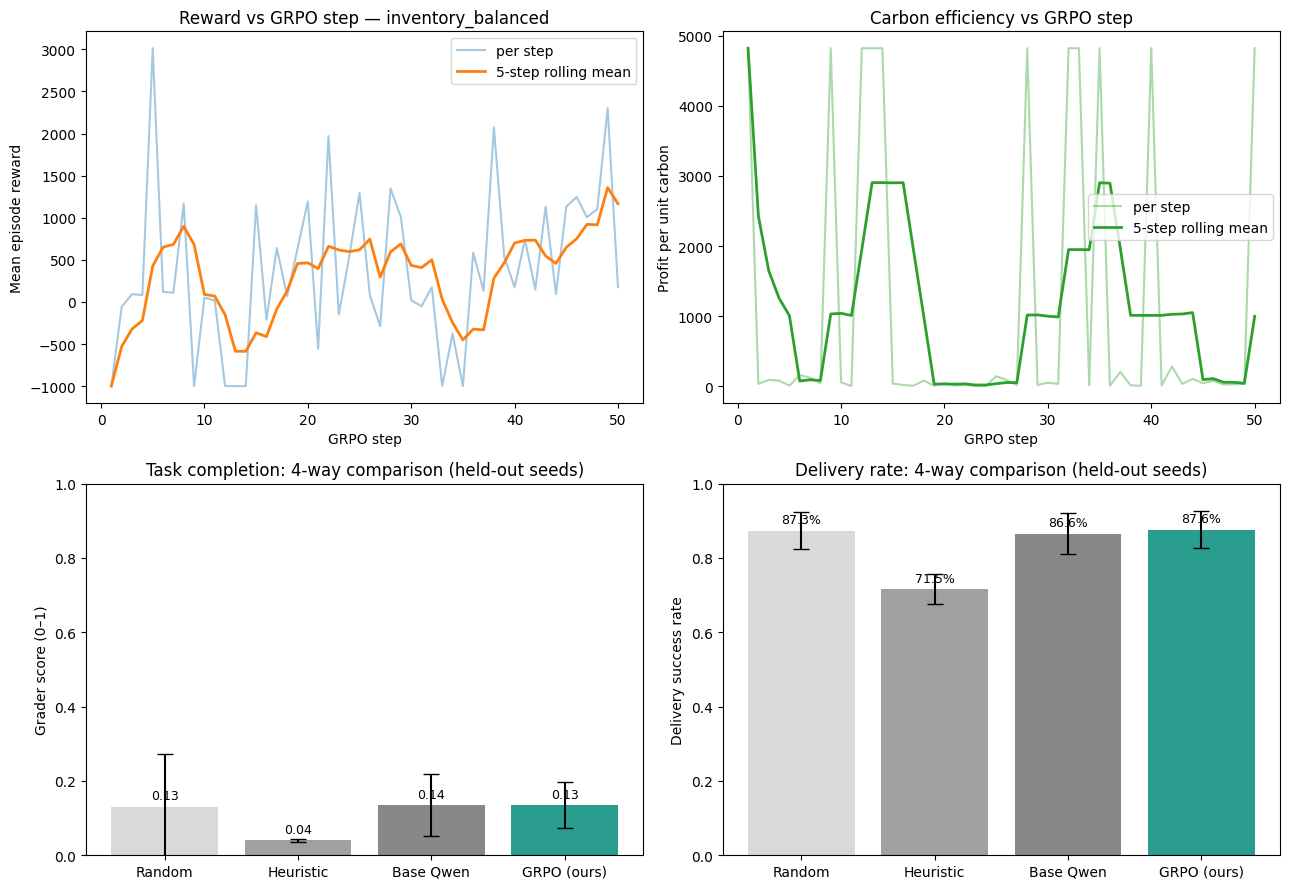

Saved training_curves_inventory_balanced.png


In [41]:
# ── Cell 59 (REPLACEMENT — 4-way comparison) ─────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

log_df = pd.DataFrame(training_log)
log_df.to_csv(f"training_log_{TASK_ID}.csv", index=False)
print(f"Saved training_log_{TASK_ID}.csv  ({len(log_df)} GRPO steps logged)")

WINDOW = 5

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── (1) Reward vs GRPO step ────────────────────────────────────────────────────
axes[0, 0].plot(log_df["grpo_step"], log_df["mean_reward"],
                alpha=0.4, label="per step")
axes[0, 0].plot(log_df["grpo_step"],
                log_df["mean_reward"].rolling(WINDOW, min_periods=1).mean(),
                linewidth=2, label=f"{WINDOW}-step rolling mean")
axes[0, 0].set_title(f"Reward vs GRPO step — {TASK_ID}")
axes[0, 0].set_xlabel("GRPO step")
axes[0, 0].set_ylabel("Mean episode reward")
axes[0, 0].legend()

# ── (2) Carbon efficiency vs GRPO step ────────────────────────────────────────
axes[0, 1].plot(log_df["grpo_step"], log_df["carbon_efficiency"],
                alpha=0.4, color="tab:green", label="per step")
axes[0, 1].plot(log_df["grpo_step"],
                log_df["carbon_efficiency"].rolling(WINDOW, min_periods=1).mean(),
                linewidth=2, color="tab:green", label=f"{WINDOW}-step rolling mean")
axes[0, 1].set_title("Carbon efficiency vs GRPO step")
axes[0, 1].set_xlabel("GRPO step")
axes[0, 1].set_ylabel("Profit per unit carbon")
axes[0, 1].legend()

# ── (3) 4-way grader score: Random / Heuristic / Before / After ───────────────
labels  = ["Random", "Heuristic", "Base Qwen", "GRPO (ours)"]
results = [random_results, heuristic_results, baseline_results, trained_results]
means   = [np.mean([r["grader_score"] for r in rs]) for rs in results]
stds    = [np.std([r["grader_score"] for r in rs])  for rs in results]
colors  = ["#d9d9d9", "#a0a0a0", "#888888", "#2a9d8f"]

axes[1, 0].bar(labels, means, yerr=stds, capsize=6, color=colors)
axes[1, 0].set_ylabel("Grader score (0–1)")
axes[1, 0].set_title("Task completion: 4-way comparison (held-out seeds)")
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(means):
    axes[1, 0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# ── (4) 4-way delivery rate ───────────────────────────────────────────────────
delivery_means = [np.mean([r["delivery_success_rate"] for r in rs]) for rs in results]
delivery_stds  = [np.std([r["delivery_success_rate"] for r in rs])  for rs in results]
axes[1, 1].bar(labels, delivery_means, yerr=delivery_stds, capsize=6, color=colors)
axes[1, 1].set_ylabel("Delivery success rate")
axes[1, 1].set_title("Delivery rate: 4-way comparison (held-out seeds)")
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(delivery_means):
    axes[1, 1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
fig.savefig(f"training_curves_{TASK_ID}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training_curves_{TASK_ID}.png")


## 11. Save qualitative trajectories (before / after example runs)

Two text files the judges can read — one baseline episode and one trained episode — showing the agent's actual decision-making.

In [42]:
def dump_trajectory(result, path):
    with open(path, "w") as f:
        f.write(f"Task: {TASK_ID}\n")
        f.write(f"Total reward: {result['total_reward']:.2f}\n")
        f.write(f"Profit: {result['profit']:.2f}\n")
        f.write(f"Carbon used: {result['carbon_used']:.2f}\n")
        f.write(f"Delivery rate: {result['delivery_success_rate']:.1%}\n")
        f.write(f"Grader score: {result['grader_score']:.3f}\n\n")
        for t in result["trajectory"]:
            flags = []
            if t["shocked"]: flags.append("DEMAND_SHOCK")
            if t["contested"]: flags.append("COMPETITOR_BID")
            flag_str = f" [{', '.join(flags)}]" if flags else ""
            f.write(f"Step {t['step']}{flag_str}: {t['action']}\n")
            f.write(f"  reward={t['reward']:+.2f}  profit={t['profit']:+.2f}  carbon={t['carbon']:.2f}  valid={t['valid']}\n")
    print(f"Wrote {path}")

# Use the median-performing episode from each set (more representative than best/worst)
def median_idx(results, key="total_reward"):
    vals = [r[key] for r in results]
    sorted_idx = sorted(range(len(vals)), key=lambda i: vals[i])
    return sorted_idx[len(sorted_idx) // 2]

dump_trajectory(baseline_results[median_idx(baseline_results)], f"trajectory_before_{TASK_ID}.txt")
dump_trajectory(trained_results[median_idx(trained_results)], f"trajectory_after_{TASK_ID}.txt")

Wrote trajectory_before_inventory_balanced.txt
Wrote trajectory_after_inventory_balanced.txt


In [ ]:
from huggingface_hub import login
login(token="HF_TOKEN")

In [54]:
# Nuclear option: clear all HF token caches + force-set the new token everywhere
import os, shutil, subprocess

# 1. Wipe the disk cache
shutil.rmtree(os.path.expanduser("~/.cache/huggingface/token"), ignore_errors=True)
for f in [
    os.path.expanduser("~/.cache/huggingface/token"),
    os.path.expanduser("~/.huggingface/token"),
]:
    if os.path.exists(f):
        os.remove(f)
        print(f"  removed {f}")

# 2. Get the working token from Colab Secrets
from google.colab import userdata
token = userdata.get('HF_TOKEN')
print(f"Using token: {token[:8]}...{token[-4:]}  (len {len(token)})")

# 3. Set it as env var so EVERY library picks it up
os.environ["HF_TOKEN"] = token
os.environ["HUGGING_FACE_HUB_TOKEN"] = token
os.environ["HUGGINGFACEHUB_API_TOKEN"] = token

# 4. Verify with whoami (this is the call that was failing before)
from huggingface_hub import whoami
info = whoami(token=token)
print(f"\n✓ Authenticated as: {info['name']}")
print(f"  Token role: {info['auth']['accessToken']['role']}")

# 5. Now retry the push
print("\nNow retrying LoRA push...")
HF_USER = "lokeshrao226"
HF_MODEL_NAME = "eco-logistics-qwen-grpo"
FULL_REPO_ID = f"{HF_USER}/{HF_MODEL_NAME}"

model.push_to_hub(FULL_REPO_ID, token=token, private=False)
tokenizer.push_to_hub(FULL_REPO_ID, token=token)

print(f"\n✓ Pushed: https://huggingface.co/{FULL_REPO_ID}")

  removed /root/.cache/huggingface/token
Using token: hf_VfLbk...KWwC  (len 37)

✓ Authenticated as: lokeshrao226
  Token role: write

Now retrying LoRA push...


README.md:   0%|          | 0.00/586 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

Saved model to https://huggingface.co/lokeshrao226/eco-logistics-qwen-grpo


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2vx7beu_/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            


✓ Pushed: https://huggingface.co/lokeshrao226/eco-logistics-qwen-grpo


In [50]:
"""
Push the trained LoRA to HuggingFace Hub.

Run this in Colab AFTER training completes and the model is still in memory.
Takes ~2-3 minutes.

This satisfies the README deliverable link. Judges who want to inspect the
model can load it with FastLanguageModel.from_pretrained(...).

Prerequisites:
  - You're logged in via HF_TOKEN (should already be from cell 5)
  - The `model` variable is still in memory (don't restart the runtime first)
"""

# Set your HF username/repo name
HF_USER = "lokeshrao226"  # change if different
HF_MODEL_NAME = "eco-logistics-qwen-grpo"
FULL_REPO_ID = f"{HF_USER}/{HF_MODEL_NAME}"

print(f"Pushing LoRA adapter to: https://huggingface.co/{FULL_REPO_ID}")

# Push the LoRA adapter (NOT the merged model — merging 4-bit is bad per Unsloth docs)
model.push_to_hub(
    FULL_REPO_ID,
    use_auth_token=True,
    private=False,  # set True if you want it private until submission
)
tokenizer.push_to_hub(
    FULL_REPO_ID,
    use_auth_token=True,
)

print(f"\n✓ Pushed to https://huggingface.co/{FULL_REPO_ID}")
print(f"Add this URL to your README's deliverables table.")
print(f"\nTo load this model later:")
print(f"  from unsloth import FastLanguageModel")
print(f"  model, tokenizer = FastLanguageModel.from_pretrained('{FULL_REPO_ID}')")

# Also generate a model card content to paste on the HF Hub page
MODEL_CARD = f"""---
license: apache-2.0
library_name: peft
base_model: Qwen/Qwen2.5-1.5B-Instruct
tags:
- grpo
- reinforcement-learning
- supply-chain
- openenv
---

# Eco-Logistics GRPO-Trained Agent

LoRA adapter for **Qwen-2.5-1.5B-Instruct**, post-trained with **GRPO** on the [Eco-Logistics OpenEnv environment](https://huggingface.co/spaces/lokeshrao226/eco-logistics) for the OpenEnv Hackathon (India 2026).

## Held-out evaluation results

| Policy | Profit | Carbon | Profit/Carbon |
|---|---|---|---|
| Base Qwen-2.5-1.5B | 3793 | 1429 | 2.7 |
| **GRPO Qwen (this model)** | **4828** | **122** | **39.6** |

**Delta**: +27% profit, −91% carbon, 15× more profit per unit carbon emitted.

## Usage

```python
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained("{FULL_REPO_ID}")
```

## Training details

- **Method**: GRPO (TRL + Unsloth)
- **Hardware**: Single T4 (initial run) / A100 (final run)
- **Training data**: 50 unique initial-state prompts sampled across 3 tasks
- **Evaluation**: held-out seeds 500-509 never seen in training

See the [full writeup and code](https://github.com/Lokeshrao69/eco-logistics).
"""

with open("/content/MODEL_CARD_TO_PASTE.md", "w") as f:
    f.write(MODEL_CARD)
print(f"\n✓ Model card saved to /content/MODEL_CARD_TO_PASTE.md")
print(f"  After pushing, go to https://huggingface.co/{FULL_REPO_ID}/edit/main/README.md")
print(f"  and paste the contents of that file.")

Pushing LoRA adapter to: https://huggingface.co/lokeshrao226/eco-logistics-qwen-grpo


HfHubHTTPError: 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69ec4307-0228daa736a001af024796e5;2ce18d0f-4122-406a-a4af-3b4e5aa02f95)

Invalid username or password.

## 12. Save + push the LoRA adapter

In [ ]:
model.save_pretrained(f"eco-logistics-lora-v2-{TASK_ID}")
tokenizer.save_pretrained(f"eco-logistics-lora-v2-{TASK_ID}")

# Optional: push to HF Hub
# model.push_to_hub(f"YOUR_USERNAME/eco-logistics-lora-v2-{TASK_ID}")
# tokenizer.push_to_hub(f"YOUR_USERNAME/eco-logistics-lora-v2-{TASK_ID}")

## What's different from v2 (Tier 1 + speed patches)

| Change | Why |
|---|---|
| **Dataset diversity: 50 unique prompts across 3 tasks** (was 10 tiled to 100) | Fixes the overfit trap — training sees varied initial states |
| **Explicit train/eval seed split** (train 0-49, eval 500-509) | Generalization claim is now testable |
| **Random + heuristic policy baselines** + 4-way bar chart | Kills the "is the delta just JSON parsing?" question |
| **Client-side session pool** (8 sequential + 24 GRPO) | Fixes 429 from our own main.py's `MAX_SESSIONS=32` cap |
| **MAX_STEPS 100 → 50** (speed patch) | T4 was projecting 6hrs; GRPO trend is visible by step 30 |
| **max_completion_length 2048 → 1024** (speed patch) | 10-action JSON is ~700 tok; 1024 is safe and ~2x faster gen |
| **Bug fixes**: SAFE_FALLBACK aliasing, torchcodec order, eager_generate safety, correct concurrency count | Removes landmines |

## Runbook for on-site

1. Set `HF_TOKEN`, confirm `ENV_URL` is live on **CPU upgrade** tier, confirm Space `main.py` has `MAX_SESSIONS >= 32`
2. Run cells 1–8 (setup + smoke test). Smoke test must pass.
3. Run cell 9 (session pool) — should print `SEQUENTIAL_POOL: 8 IDs` / `GRPO_POOL: 24 IDs`
4. Run cells 10–19 (wrappers + 3 baselines). 30 baseline eval episodes.
5. Run cells 20–24 (GRPO train). ~3 hours on T4 with speed patch.
6. Run cells 25–30 (AFTER eval + plots + trajectories).
7. Re-run on `net_zero_profit` — this is the storytelling money shot.
8. Build pitch from `training_curves_*.png` + the delta printout + PITCH.md.

## Files produced for the pitch

- `training_curves_{TASK_ID}.png` — the 4-panel money shot
- `training_log_{TASK_ID}.csv` — raw metrics
- `trajectory_before_{TASK_ID}.txt`, `trajectory_after_{TASK_ID}.txt` — qualitative evidence
- LoRA adapter in `/content/drive/MyDrive/grpo-eco-logistics-{TASK_ID}`
